# Titanic Exploration df Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from configs.config_titanic import config

%load_ext autoreload
%matplotlib inline

## Basic dfset info

In [2]:
df = pd.read_csv(config.paths.train)
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


*Nulls*

In [3]:
df.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

**Notes** for dfset first look
1. Identification columns `PassengerId`, `Ticket` are first to drop;
2. Column `Name` should be dropped too, but need to mine possible useful df such as age assumption for samples with `NaN` in `Age` column;

## Features and target analysis

***Correlation matrix***

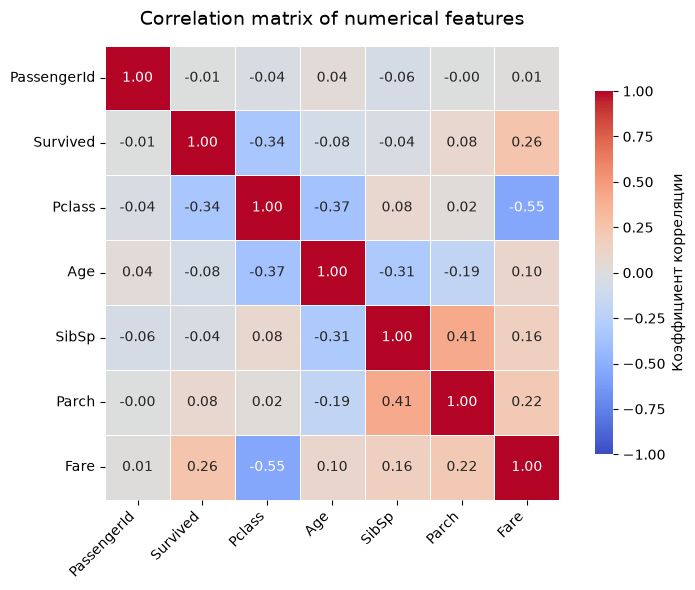

In [4]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'},
)

plt.title(
    f'Correlation matrix of numerical features', fontsize=14, pad=15
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Notes** for the features correlation:
1. One strong correlation between `SibSp` and `Parch` features is observed - both may be generalized to a `Family_Size` feature;
2. Correlations between features and targets. `Fare` feature has relatively great correlation with the target. I assume that rich people had more chances to survive;

***Target distribution***

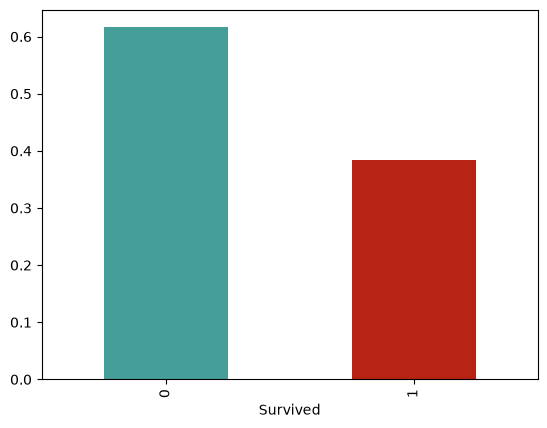

In [5]:
df[config.general.target].value_counts(normalize=True).plot.bar(color=["#469E98", "#B72414"])
plt.show()

***Feautures distribution***

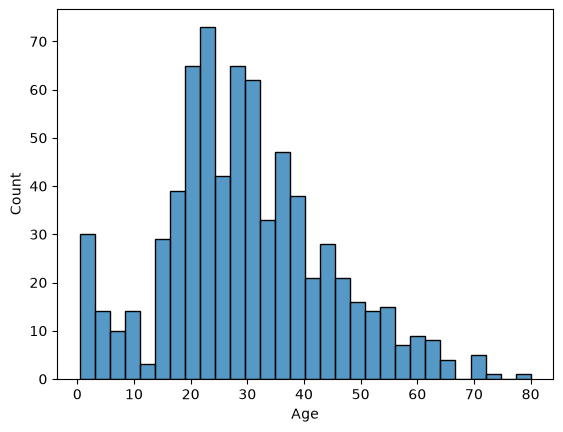

In [6]:
sns.histplot(df['Age'], bins=30)
plt.show()

***Possible transformation for the Age feature***

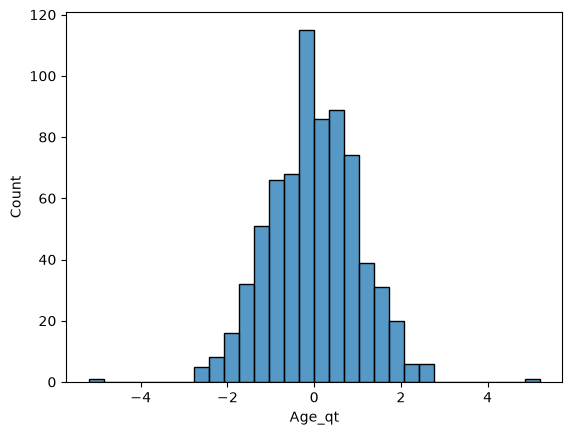

In [7]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(
    n_quantiles=100,
    random_state=config.general.random_state,
    output_distribution='normal'
)

df['Age_qt'] = qt.fit_transform(df[['Age']])

sns.histplot(df['Age_qt'], bins=30)
plt.show()

***The Age feature distribution regarding to the target label***

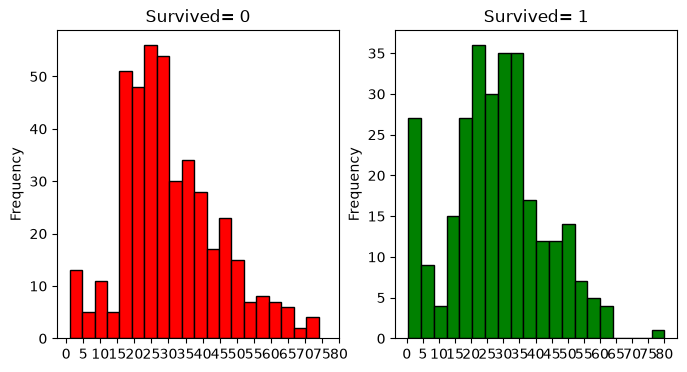

In [8]:
f,ax=plt.subplots(1,2,figsize=(20,10))
df[df['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red', figsize=(8,4))
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
df[df['Survived']==1].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black', figsize=(8,4))
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

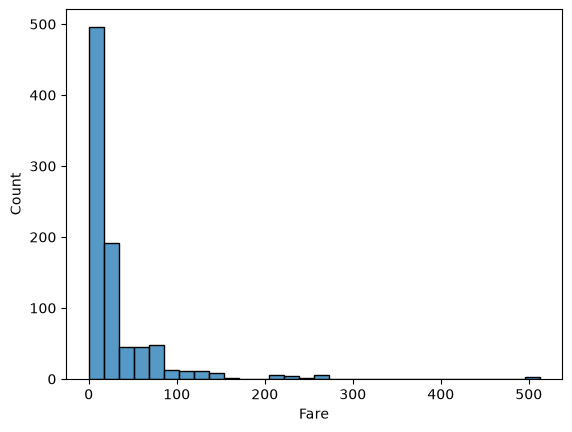

In [9]:
sns.histplot(df['Fare'], bins=30)
plt.show()

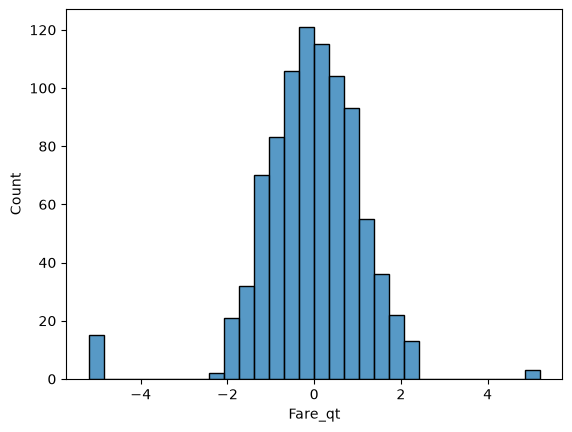

In [10]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(
    n_quantiles=100,
    random_state=config.general.random_state,
    output_distribution='normal'
)

df['Fare_qt'] = qt.fit_transform(df[['Fare']])

sns.histplot(df['Fare_qt'], bins=30)
plt.show()

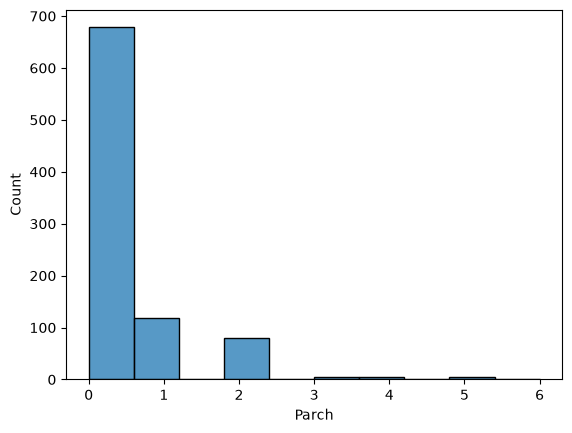

In [11]:
sns.histplot(df['Parch'], bins=10)
plt.show()

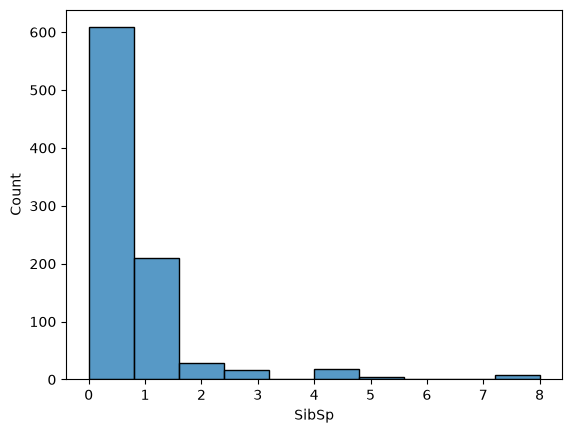

In [12]:
sns.histplot(df['SibSp'], bins=10)
plt.show()

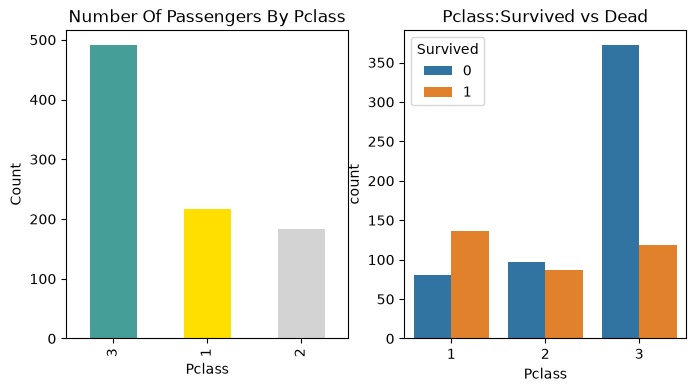

In [13]:
f,ax=plt.subplots(1,2,figsize=(8,4))
df['Pclass'].value_counts().plot.bar(color=["#469E98",'#FFDF00','#D3D3D3'],ax=ax[0])
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
sns.countplot(x='Pclass',hue='Survived',data=df,ax=ax[1])
ax[1].set_title('Pclass:Survived vs Dead')
plt.show()

**Notes** for the features distribution:
1. The `Age` feature has relatively strong impact to possible rescue as kids were the prior target to save.
2. Quantile transformations for `Fare` and `Age` features are doubtful but worth trying. May be an outlier in `Fare` feature (~500) - needs to be investigated.
3. Pclass has approximately uniform distribution and hasn't big chances to give a strong impact to target prediction;

In [17]:
df[df['Fare'] > 300]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_qt,Fare_qt
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,0.472789,5.199338
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,0.559592,5.199338
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,0.472789,5.199338


4. Samples with big `Fare` value can't be removed since the have positive label. Therefore, QuanileTransformer may be useful for normalizing this variance 